# Lego Minifigure Multilabel Vision - Training Pipeline

Notebook version of `main.py`. Runs the full pipeline end to end: data prep -> transfer-learning model -> training (MPS, mixed precision) -> evaluation -> Grad-CAM -> save artifacts.

It also persists `history`, the classification report, and run metadata to `outputs/metrics/` so they can be turned into a report.

## 0. Bootstrap (make the project importable from any launch dir)

In [1]:
import os, sys
from pathlib import Path

_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / "scripts" / "model.py").exists()), _here)
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("Working dir:", Path.cwd())

Working dir: /Users/veto/Documents/git/kul-advanced-analytics/proj2


## 1. Setup, logging & versioning

In [ ]:
import logging, json, pickle
import torch
from datetime import datetime
from torch.optim import Adam
from torch.nn import BCEWithLogitsLoss
from torch.utils.tensorboard import SummaryWriter

from scripts.dataset import prepare_dataframes, get_dataloaders
from scripts.model import build_model
from scripts.train import train_model
from scripts.evaluate import evaluate_model
from scripts.interpret import generate_gradcam
import scripts.config as config

# Train for 200 epochs (long enough for the loss curves to flatten out / plateau).
# We override the attribute here rather than in config.py so main.py keeps its default of 20 runs
config.EPOCHS = 200

# Unique ID for this exact execution, e.g. "20260526_201233". Every artifact
# (logs, plots, metrics) is suffixed with it -> "{name}_{yyyymmdd}_{hhmmss}".
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

os.makedirs("outputs/logs", exist_ok=True)
os.makedirs("outputs/saved_models", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

log_filename = f"outputs/logs/training_log_{run_id}.txt"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.FileHandler(log_filename), logging.StreamHandler()],
    force=True,  # in a notebook the root logger may already have handlers
)
tb_writer = SummaryWriter(f"outputs/logs/tensorboard_{run_id}")

logging.info(f"--- Starting new pipeline run: {run_id} ---")
logging.info(f"Using device: {config.DEVICE}")
logging.info(f"Epochs: {config.EPOCHS} | Mixed precision (AMP): {config.USE_AMP} | DataLoader workers: {config.NUM_WORKERS} | Batch size: {config.BATCH_SIZE}")
print("run_id:", run_id)

## 2. Data preparation

In [3]:
data_dir = "./data"
json_path = "./data/minifigs.json"

train_df, val_df, test_df, mlb, pos_weight_tensor = prepare_dataframes(
    json_path=json_path, data_dir=data_dir, top_k=config.TOP_K
)
num_classes = len(mlb.classes_)
logging.info(f"Data prepped. Training to predict {num_classes} Lego categories.")
print("Classes:", list(mlb.classes_))
print("Split sizes -> train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))

train_loader, val_loader, test_loader = get_dataloaders(
    train_df, val_df, test_df, batch_size=config.BATCH_SIZE
)

/Users/veto/Documents/git/kul-advanced-analytics/proj2/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['4 Juniors', 'Action Wheelers', 'Advanced models', 'Adventurers', 'Agents', 'Alpha Team', 'Animal Crossing', 'Aqua Raiders', 'Aquazone', 'Architecture', 'Assorted', 'Atlantis', 'Avatar', 'Avatar: The Last Airbender', 'Baby', 'Basic', 'Batman', 'Belville', 'Bionicle', 'Bluey', 'Boats', 'Books', 'Bricks and More', 'Building Set with People', 'Bulk Bricks', 'Cars', 'Classic', 'Clikits', 'Creator', 'Creator Expert', 'DC Super Hero Girls', 'Despicable Me', 'Dimensions', 'Dino', 'Dino 2010', 'Dino Attack', 'Discovery', 'Dreamzzz', 'Elves', 'Exo-Force', 'Explore', 'Fabuland', 'Factory', 'Fortnite', 'Freestyle', 'Fusion', "Gabby's Dollhouse", 'Games', 'Gear', 'Ghostbusters', 'HERO Factory', 'Hidden Side', 'Homemaker', 'Horizon', 'Indiana Jones', 'Island Xtreme Stunts', 'Jack Stone', 'Juniors', 'Jurassic World', 'LEGO Universe', 'LEGOLAN

Classes: ['City', 'Star Wars', 'Ninjago', 'Friends', 'Duplo', 'Collectable Minifigures', 'Marvel Super Heroes', 'Town', 'Harry Potter', 'Castle', 'Education', 'Disney', 'DC Comics Super Heroes', 'Icons', 'Ideas', 'BrickLink', 'Promotional', 'Dacta', 'Minecraft', 'Sports']
Split sizes -> train: 12152 | val: 2604 | test: 2605


## 3. Build model (ResNet18 transfer learning)

In [4]:
logging.info("Building model and moving to device...")
ini_model = build_model(num_classes).to(config.DEVICE)
pos_weight_tensor = pos_weight_tensor.to(config.DEVICE)
criterion = BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = Adam(filter(lambda p: p.requires_grad, ini_model.parameters()), lr=config.LEARNING_RATE)

2026-05-26 16:31:13,050 [INFO] Building model and moving to device...


## 4. Train

In [5]:
logging.info("Starting training loop...")
trained_model, history = train_model(
    ini_model, train_loader, val_loader, criterion, optimizer,
    config.DEVICE, run_id=run_id, tb_writer=tb_writer,
)

# Persist training history for the report.
with open(f"outputs/metrics/history_{run_id}.json", "w") as f:
    json.dump(history, f, indent=2)

2026-05-26 16:31:13,205 [INFO] Starting training loop...



Epoch 1/20
--------------------


2026-05-26 16:31:51,220 [INFO] Train Loss: 0.0686 | Train Acc: 0.5114


2026-05-26 16:31:51,221 [INFO] Val Loss:   0.0489 | Val Acc:   0.6197


2026-05-26 16:31:51,221 [INFO] Validation loss improved from inf to 0.0489. Saving model...


...

2026-05-26 16:36:21,283 [INFO] Train Loss: 0.0345 | Train Acc: 0.8139


2026-05-26 16:36:21,283 [INFO] Val Loss:   0.0378 | Val Acc:   0.7828


2026-05-26 16:36:21,284 [INFO] Validation loss improved from 0.0382 to 0.0378. Saving model...


2026-05-26 16:36:21,368 [INFO] Training Complete!


2026-05-26 16:36:21,418 [INFO] Loaded best model weights for evaluation.


## 5. Evaluate on the test set

2026-05-26 16:36:21,425 [INFO] Evaluating model on test set...



--- Multilabel Classification Report ---
                         precision    recall  f1-score   support

                   City       0.47      0.72      0.57       311
              Star Wars       0.37      0.81      0.51       230
                Ninjago       0.23      0.90      0.36       135
                Friends       0.50      0.99      0.66       124
                  Duplo       0.38      0.99      0.55       138
Collectable Minifigures       0.10      0.83      0.18       106
    Marvel Super Heroes       0.17      0.82      0.28       100
                   Town       0.17      0.94      0.29        81
           Harry Potter       0.20      0.91      0.32       107
                 Castle       0.14      0.90      0.24        70
              Education       0.06      0.91      0.11        67
                 Disney       0.10      0.89      0.17        56
 DC Comics Super Heroes       0.08      0.85      0.15        53
                  Icons       0.03      0.80   

/Users/veto/Documents/git/kul-advanced-analytics/proj2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/veto/Documents/git/kul-advanced-analytics/proj2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/veto/Documents/git/kul-advanced-analytics/proj2/scripts/evaluate.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

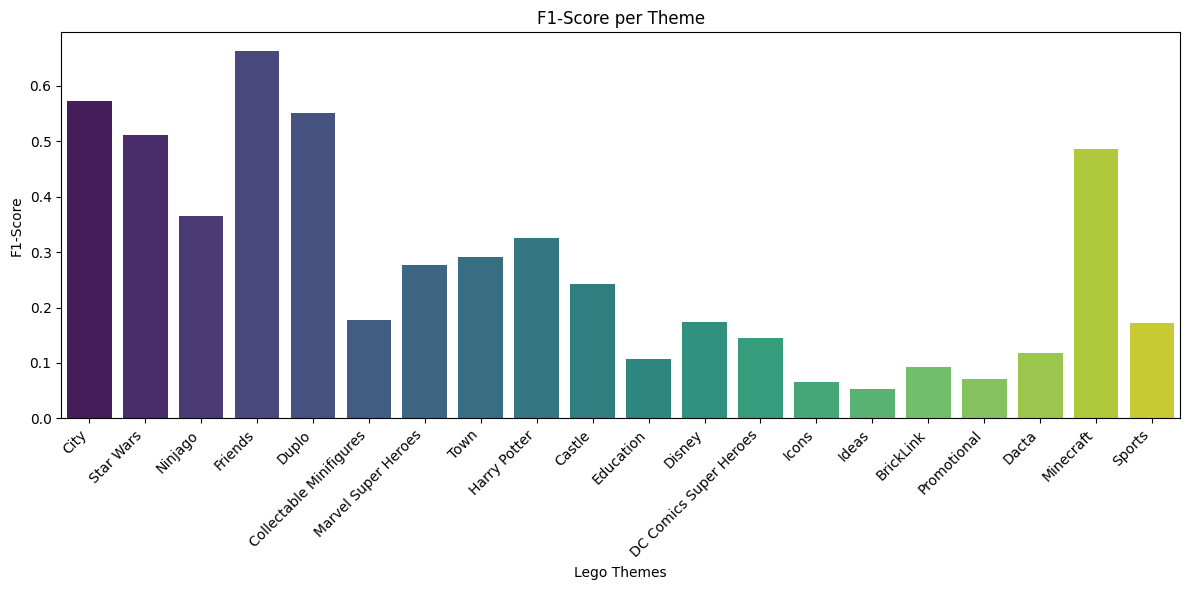

In [6]:
logging.info("Evaluating model on test set...")
report_dict = evaluate_model(trained_model, test_loader, config.DEVICE, mlb, run_id)

# Persist the multilabel classification report for the report.
with open(f"outputs/metrics/report_{run_id}.json", "w") as f:
    json.dump(report_dict, f, indent=2)
print("micro avg F1:", round(report_dict["micro avg"]["f1-score"], 4))
print("macro avg F1:", round(report_dict["macro avg"]["f1-score"], 4))

## 6. Interpretability (Grad-CAM)

2026-05-26 16:36:37,447 [INFO] Generating Interpretability Visualizations...


Generating Comparative Grad-CAM visualization (3 Correct, 3 Incorrect)...


Comparison Grad-CAM saved to outputs/plots/gradcam_comparison_opus47v1.png


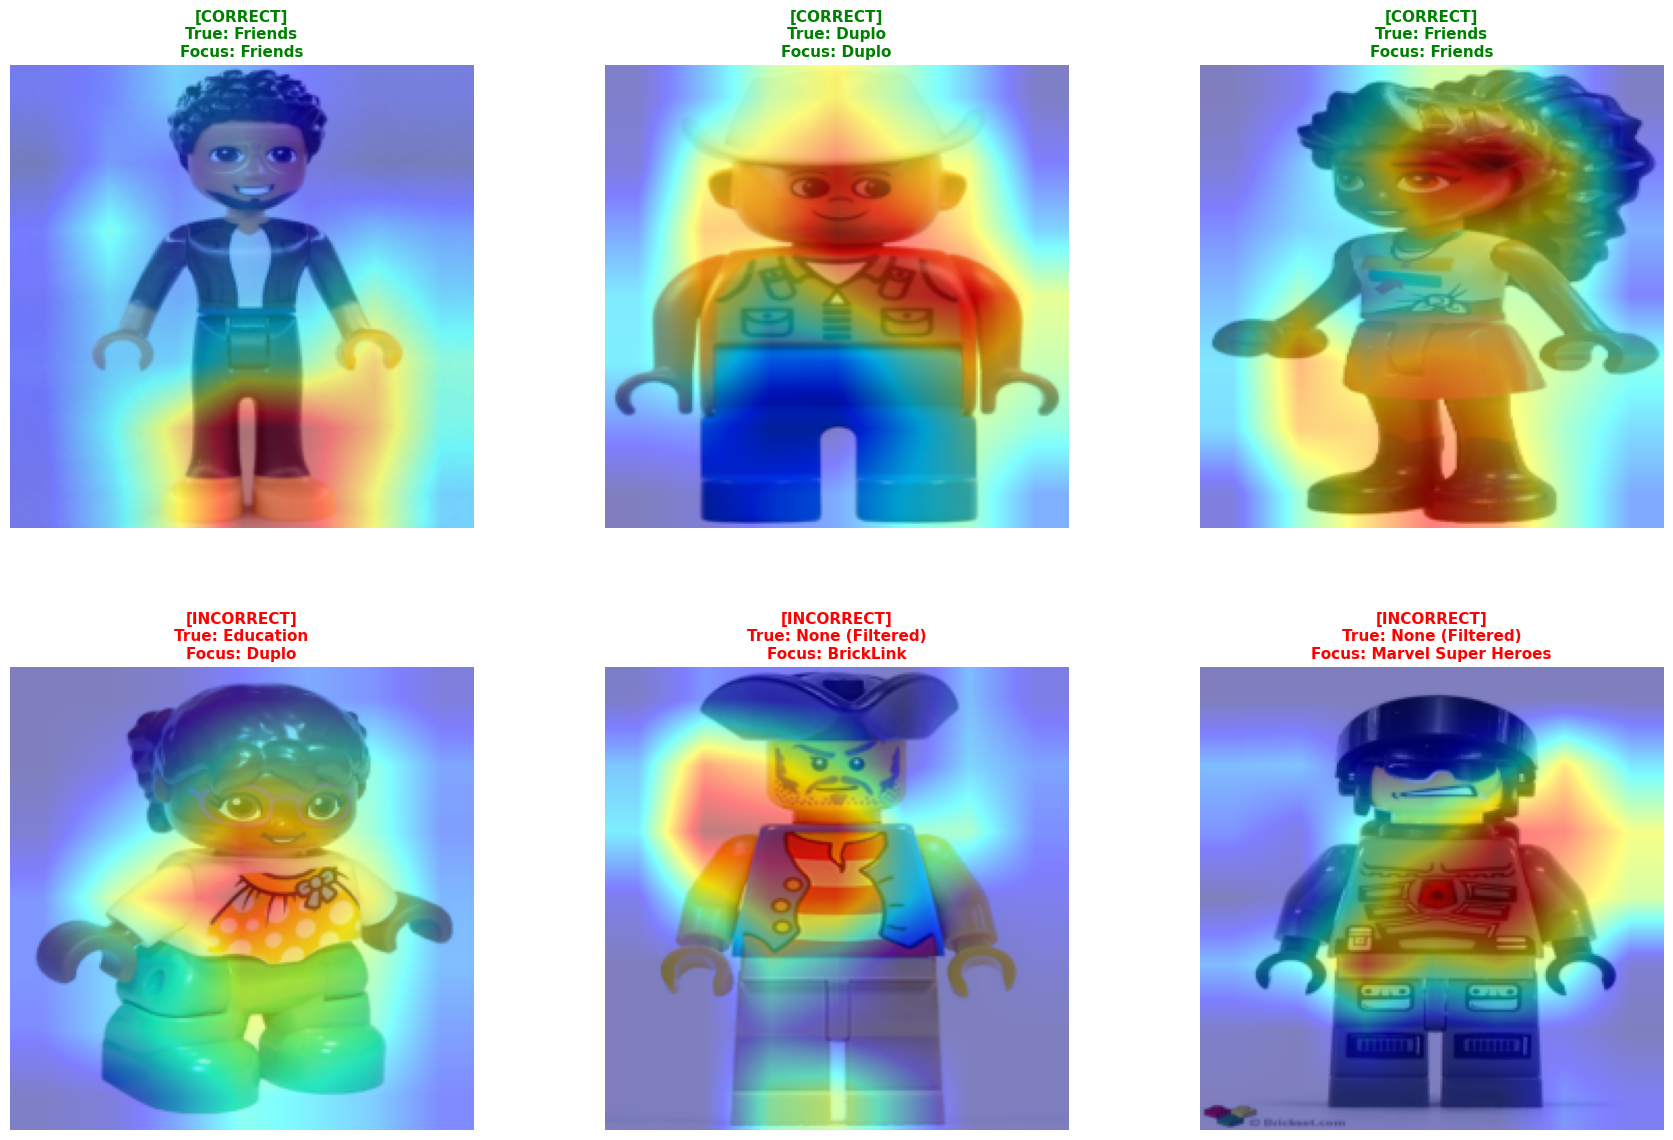

In [7]:
logging.info("Generating Interpretability Visualizations...")
generate_gradcam(trained_model, test_loader, config.DEVICE, mlb, run_id)

## 7. Save artifacts & run metadata

In [8]:
logging.info("Saving final model...")
save_dir = "outputs/saved_models"
os.makedirs(save_dir, exist_ok=True)

final_model_path = f"{save_dir}/production_lego_model.pth"
torch.save(trained_model.state_dict(), final_model_path)

encoder_path = f"{save_dir}/label_encoder.pkl"
with open(encoder_path, "wb") as f:
    pickle.dump(mlb, f)

logging.info(f"Pipeline complete! Model saved to {final_model_path}")
logging.info(f"Label encoder saved to {encoder_path}")
tb_writer.close()

run_meta = {
    "run_id": run_id,
    "device": str(config.DEVICE),
    "use_amp": config.USE_AMP,
    "batch_size": config.BATCH_SIZE,
    "epochs": config.EPOCHS,
    "learning_rate": config.LEARNING_RATE,
    "num_workers": config.NUM_WORKERS,
    "num_classes": int(num_classes),
    "classes": list(mlb.classes_),
    "split_sizes": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
}
with open(f"outputs/metrics/run_meta_{run_id}.json", "w") as f:
    json.dump(run_meta, f, indent=2)

logging.info("Pipeline completed successfully.")
print("DONE")

2026-05-26 16:36:40,548 [INFO] Saving final model...


2026-05-26 16:36:40,615 [INFO] Pipeline complete! Model saved to outputs/saved_models/production_lego_model.pth


2026-05-26 16:36:40,615 [INFO] Label encoder saved to outputs/saved_models/label_encoder.pkl


2026-05-26 16:36:40,617 [INFO] Pipeline completed successfully.


DONE
